# 实验十八：基于区域的图像分割与四叉树

## 1. 实际应用场景
基于区域的分割算法在以下领域有广泛应用：
*   **医学影像分析**：在 CT 或 MRI 图像中，医生通常需要提取特定的器官或肿瘤。通过在病灶区域手动点击一个“种子点”，区域生长算法可以自动将具有相似对比度的病变组织提取出来。
*   **卫星遥感地物分类**：在处理高分辨率遥感图像时，通过分裂合并算法可以将森林、水域或城市建筑划分为同质区域，四叉树结构能有效减少计算量并处理大规模数据。
*   **工业缺陷检测**：在光滑的金属表面或布料生产线上，利用区域相似性准则可以快速识别出颜色或纹理异常的瑕疵点。

--- 
## 2. 实验目的
学习脱离传统的边缘检测和全局阈值，转而基于**像素相似性准则**（如灰度值相似、纹理相似等）分割同质区域。掌握空间域分割的两种核心策略：自底向上的区域生长与自顶向下的分裂合并。

## 3. 实验准备
我们将使用 `OpenCV`, `NumPy` 和 `Matplotlib`。

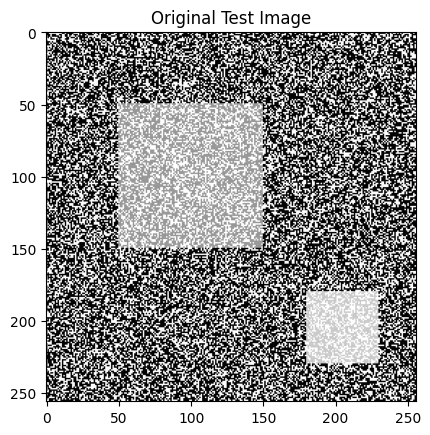

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 生成一个简单的测试图像：带噪声的块状目标
def create_test_image():
    img = np.zeros((256, 256), dtype=np.uint8)
    img[50:150, 50:150] = 150 # 目标块1
    img[180:230, 180:230] = 200 # 目标块2
    # 添加高斯噪声
    noise = np.random.normal(0, 5, img.shape).astype(np.uint8)
    img = cv2.add(img, noise)
    return img

test_img = create_test_image()
plt.imshow(test_img, cmap='gray')
plt.title("Original Test Image")
plt.show()

--- 
## 4. 任务一：编写区域生长（Region Growing）算法

**基本原理**：
1. 选择一个或多个种子点（Seeds）。
2. 检查种子点相邻的像素，如果符合相似性准则（例如灰度差在一定阈值内），则将其合并到区域中。
3. 重复上述过程，直到没有符合条件的像素可以添加。

**练习**：实现一个简单的灰度相似性区域生长。

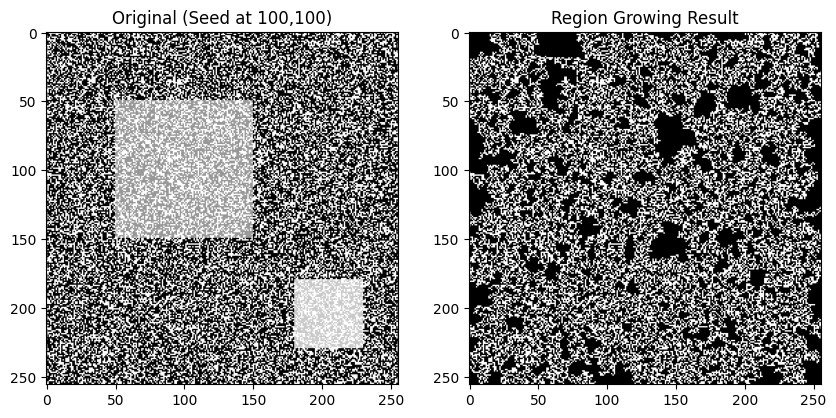

In [14]:
def region_growing(img, seed, threshold):
    """
    img: 灰度图像
    seed: 种子点坐标 (x, y)
    threshold: 相似性阈值（灰度差上限）
    """
    h, w = img.shape
    # 创建输出图像，初始化为0
    segmented = np.zeros_like(img)
    # 记录已访问的像素
    visited = np.zeros_like(img, dtype=bool)
    
    # 待处理像素队列
    pixel_list = [seed]
    segmented[seed[1], seed[0]] = 255
    visited[seed[1], seed[0]] = True
    
    # 获取种子点的初始灰度值
    seed_value = img[seed[1], seed[0]]
    
    # 8-邻域方向
    neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1), (-1, -1), (-1, 1), (1, -1), (1, 1)]
    
    while len(pixel_list) > 0:
        curr_x, curr_y = pixel_list.pop(0)
        
        for dx, dy in neighbors:
            nx, ny = curr_x + dx, curr_y + dy
            
            # 边界检查
            if 0 <= nx < w and 0 <= ny < h:
                if not visited[ny, nx]:
                    # 相似性准则：邻域灰度与种子灰度之差小于阈值
                    if abs(int(img[ny, nx]) - int(seed_value)) <= threshold:
                        segmented[ny, nx] = 255
                        pixel_list.append((nx, ny))
                    visited[ny, nx] = True
                    
    return segmented

# 测试算法
seed_pt = (100, 100) # 位于第一个方块中心
rg_result = region_growing(test_img, seed_pt, 15)

plt.figure(figsize=(10, 5))
plt.subplot(121), plt.imshow(test_img, cmap='gray'), plt.title("Original (Seed at 100,100)")
plt.subplot(122), plt.imshow(rg_result, cmap='gray'), plt.title("Region Growing Result")
plt.show()

--- 
## 5. 任务二：实现分裂与合并（Split and Merge）算法

**基本原理**：
1. **分裂**：将图像看作一个整体。如果它不是同质的（例如标准差太大），则将其分裂为四个象限（四叉树结构结构）。递归分裂直到每个块都是同质的。
2. **合并**：检查相邻的块，如果它们合并后依然符合同质性准则，则将其合并为一个区域。

由于完整的合并逻辑非常复杂，本实验重点实现**分裂**过程及利用**四叉树**可视化分割边界。

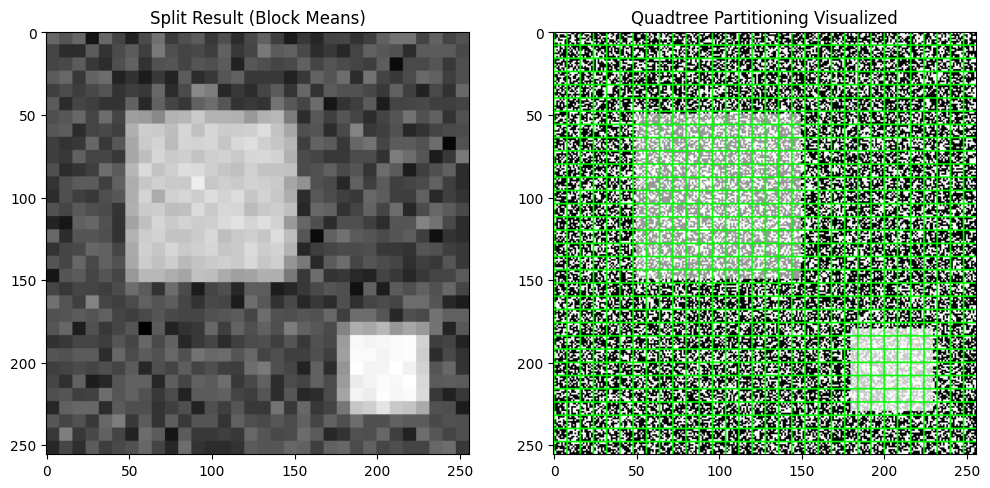

In [15]:
def is_homogeneous(region, std_threshold):
    """判断区域是否同质"""
    return np.std(region) <= std_threshold

def split_region(img, x, y, w, h, std_threshold, min_size=8):
    """
    递归分裂函数
    """
    region = img[y:y+h, x:x+w]
    
    # 如果区域足够小或已经是同质的，停止分裂
    if h <= min_size or w <= min_size or is_homogeneous(region, std_threshold):
        return [(x, y, w, h, np.mean(region))]
    
    # 否则，分裂为四个子块
    mw, mh = w // 2, h // 2
    quads = [
        (x, y, mw, mh),           # 左上
        (x + mw, y, mw, mh),      # 右上
        (x, y + mh, mw, mh),      # 左下
        (x + mw, y + mh, mw, mh)  # 右下
    ]
    
    results = []
    for qx, qy, qw, qh in quads:
        results.extend(split_region(img, qx, qy, qw, qh, std_threshold, min_size))
    return results

# 运行分裂过程
std_limit = 10
blocks = split_region(test_img, 0, 0, test_img.shape[1], test_img.shape[0], std_limit)

# 可视化结果
split_img = np.zeros_like(test_img)
canvas = cv2.cvtColor(test_img.copy(), cv2.COLOR_GRAY2BGR)

for x, y, w, h, val in blocks:
    # 将块填充为平均值
    split_img[y:y+h, x:x+w] = int(val)
    # 画出四叉树边界
    cv2.rectangle(canvas, (x, y), (x + w, y + h), (0, 255, 0), 1)

plt.figure(figsize=(12, 6))
plt.subplot(121), plt.imshow(split_img, cmap='gray'), plt.title("Split Result (Block Means)")
plt.subplot(122), plt.imshow(canvas), plt.title("Quadtree Partitioning Visualized")
plt.show()

## 6. 实验总结与思考

1. **种子点选择的影响**：在区域生长中，如果种子点选在了噪声上，会发生什么？如果目标内部灰度梯度较大，单一阈值是否能胜任？
2. **分裂合并准则**：在分裂算法中，我们使用了标准差（Std）作为同质性准则。尝试思考，如果要分割具有纹理的区域（如草地和沙地），相似性准则应该如何修改？
3. **算法对比**：
    *   **区域生长**：适合提取单一、连通的特定目标，依赖初值。
    *   **分裂合并**：能够对全图进行整体划分，结构化强，但递归深度和合并策略需要精心设计。